# Bose Hubbard Simulation

**Author:** Gabriel Maresch

In [11]:
using Pkg
using Plots
using LinearAlgebra

## Mean field ansatz

In [13]:
function build_operators(N::Int)
#Levels 0 to N
    d = [sqrt(i) for i in 1:N]
    v = [i for i in 0:N]
    a_dagger= diagm(-1=> d)
    a = diagm(1=> d)
    n = diagm(v)
    
    return a_dagger, a, n 
end

function build_mf_hamiltonian(U, J, mu, psi, N, Z=2)
    a_dag, a, n = build_operators(N::Int)
    H =  U/2*n*(n-I)
    H += - mu*n
    H += - Z*J*psi*(a_dag+a)
    H += abs(psi)^2 * I

    return H
end

build_mf_hamiltonian (generic function with 2 methods)

In [14]:
function sc_loop(H_params, N, eps0=1e-5, psi_init=1.)
    eps, i  = 1.0, 1
    U, J, mu, psi = H_params..., psi_init
    a_dag, a, n = build_operators(N)
    gs, E0 = nothing, nothing
    
    while eps > eps0
      
        H = build_mf_hamiltonian(U, J, mu, psi, N)
        F = eigen(Hermitian(H))
        gs, E0 = F.vectors[:,1], F.values[1]
        psi_new = gs'*a*gs
        # println(psi,"\t", psi_new)
        eps = abs(psi-psi_new)
        # println("loop", i, ": ", round(eps, digits = 5))
        psi = psi_new 
        i += 1
    end

    return psi, E0, gs'*n*gs
end

function plot_pseudo_potential(H_params, N_plot=100)
    U, J, mu = H_params[1], H_params[2], H_params[3] 
    psis = range(-5*J/U, 5*J/U, 100)
    Es = zeros(N_plot)
    for i in 1:N_plot
        H = build_mf_hamiltonian(U, J, mu, psis[i], N_plot)
        Es[i] = eigen(Hermitian(H)).values[1]
    end
    return plot(psis, Es, label="gs_energy", xlabel="psi", ylabel="E")
end

plot_pseudo_potential (generic function with 2 methods)

In [15]:
function classify_phase(H_params, N=10, eps0=1e-3)
    psi, _, n  = sc_loop(H_params, N)
   
    if abs(psi) < eps0
        mott = true
    else
        mott = false
    end
    
    return Int(!mott), n
end

classify_phase (generic function with 3 methods)

In [16]:
M = 251
Js = range(0.0, .15, length = M)
mus = range(0.0, 8.0, length = M)

phase = zeros(Int, M, M)
dens = zeros(M, M)
for i in 1:M
    for j in 1:M
        H_params = [1.0, Js[i], mus[j]]
        phase[i,j]= classify_phase(H_params)[1]
        dens[i,j] = classify_phase(H_params)[2]
    end
end

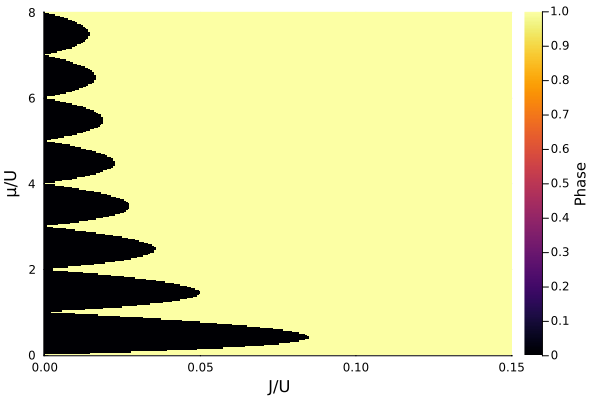

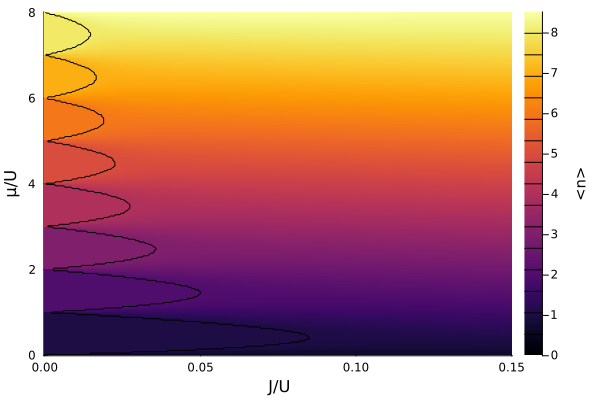

In [17]:
p1 = heatmap(Js, mus, phase', xlabel="J/U", ylabel="μ/U", colorbar_title="Phase")
p2 = heatmap(Js, mus, dens', xlabel="J/U", ylabel="μ/U", colorbar_title="<n>")
contour!(Js, mus, phase', linewidth=1, color="black")

display(p1)
display(p2)

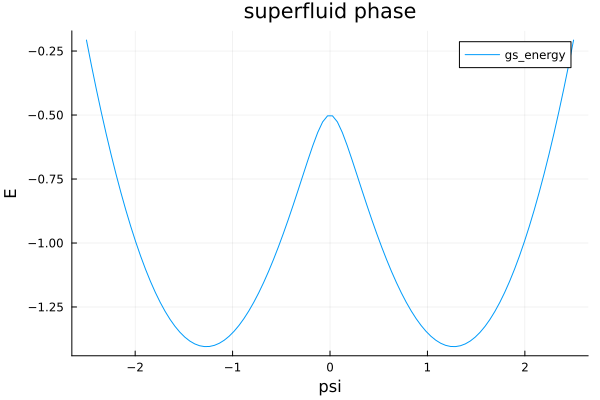

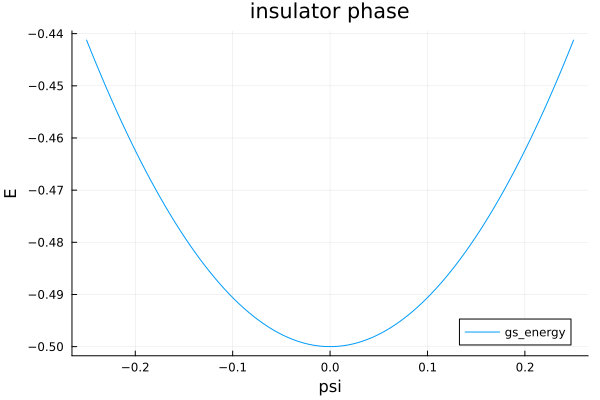

In [18]:
sf = [1.0, 0.5, 0.5]
mott = [1.0, 0.05, 0.5]

p_sf=plot_pseudo_potential(sf)
plot!(p_sf, title="superfluid phase")
display(p_sf)

p_mott=plot_pseudo_potential(mott)
plot!(p_mott, title="insulator phase")
display(p_mott)

## Two-site Bose Hubbard model

In [19]:

function bose_hubbard2(J, U, mu; N=10)
    _, a, _ = build_operators(N)
    eins = Matrix(I, N+1, N+1)
    a_L, a_R  = kron(a, eins), kron(eins, a)
    n_L, n_R  = a_L'*a_L, a_R'*a_R
    H = -J*(a_L'*a_R + a_R'* a_L) +U/2*( n_L*(n_L-kron(eins,eins))+n_R*(n_R-kron(eins,eins))) - mu*(n_L + n_R)
    
    F = eigen(Hermitian(H))
    gs, E0 = F.vectors[:,1], F.values[1]
    angle = atan(gs[2], gs[1])
    
    rho = zeros(2,2)
    rho[1,1] = gs'* a_L' * a_L * gs
    rho[1,2] = gs'* a_L' * a_R * gs
    rho[2,1] = conj(rho[1,2])
    rho[2,2] = gs'* a_R' * a_R * gs
    
    R = eigen(Hermitian(rho))
    # print("1-part", R.values)
    rho_plus, rho_minus =  R.values
    return E0, rho_plus, rho_minus, angle
end 

N_plot = 201
U, mu  = 1, 1.5
n = 1+floor(mu/U)
Js = range(0,15, length = N_plot)
E0s, rho_minus, rho_plus, thetas = [], [], [], []

for i in 1:N_plot
    E0, u, v, theta = bose_hubbard2(Js[i], U, mu; N=25)
    push!(E0s, E0)
    push!(rho_plus, v)
    push!(rho_minus, u)
    push!(thetas, theta)
end    

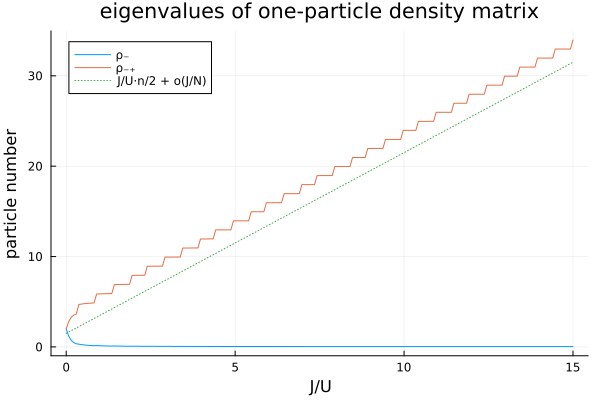

In [20]:
ev = plot(Js, rho_minus, xlabel="J/U", ylabel="particle number", label = "ρ₋", title = "eigenvalues of one-particle density matrix")
plot!(ev, Js, rho_plus, label = "ρ₋₊")
plot!(ev, Js, Js.*(n).+(mu), linestyle =:dot, label = "J/U⋅n/2 + o(J/N)")
display(ev)